# Chunk-Level XGBoost (Deployment-Safe Features)

Trains XGBoost on deployment-safe features only and evaluates at chunk level.

**Features excluded (not available at prediction time):**  
`Travel_Distance`, `same_aisle`, `same_lockey`, `same_location`, `same_level`, `diff_level`, `time_of_day`, `day_of_week`, `hour`

In [6]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import importlib
import feature_engineer
importlib.reload(feature_engineer)
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH         = Path("../data/processed")
WAREHOUSE    = "OE"
WORKCODES    = ["10", "20", "30"]
MAX_TIME     = 300
BLOCK_SIZE   = 20
RANDOM_STATE = 2026

# Features not available at prediction time — excluded from XGBoost
NOT_AVAILABLE = [
    "Travel_Distance",
    "same_aisle", "same_lockey", "same_location", "same_level", "diff_level",
    "time_of_day", "day_of_week", "hour",
]


In [7]:
def resolve_data_path(warehouse):
    return PATH / f"{warehouse.lower()}_detailed.parquet"


_df_raw = pd.read_parquet(resolve_data_path(WAREHOUSE))
_df_raw["WorkCode"] = _df_raw["WorkCode"].astype(str).apply(
    lambda x: x.split(".")[0] if isinstance(x, str) else x
)
WORKCODES = sorted(_df_raw["WorkCode"].dropna().unique().tolist())
print(f"WorkCodes found: {WORKCODES}")
del _df_raw



def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode,
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    features = [f for f in features_all if f not in NOT_AVAILABLE]
    cat_cols = [c for c in cat_cols_all if c not in NOT_AVAILABLE]
    return d, features, cat_cols


def split_by_days(df, test_ratio=0.15):
    all_days    = sorted(df["date"].dropna().unique())
    n_test_days = max(1, int(round(len(all_days) * test_ratio)))
    test_days   = all_days[-n_test_days:]
    train_df    = df[df["date"] < test_days[0]].copy()
    test_df     = df[df["date"].isin(test_days)].copy()
    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def eval_predictions(y_true, pred):
    return {
        "r2":   r2_score(y_true, pred),
        "mae":  mean_absolute_error(y_true, pred),
        "rmse": np.sqrt(mean_squared_error(y_true, pred)),
    }


def make_test_blocks(test_df, block_size=BLOCK_SIZE):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks, block_rows = [], []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.sort_values("Timestamp").reset_index().rename(columns={"index": "orig_index"}).copy()
        for start in range(0, len(g), block_size):
            chunk = g.iloc[start:start + block_size].copy()
            if len(chunk) < block_size:
                continue
            if chunk["WorkCode"].nunique() != 1:
                continue
            if (chunk["Time_Delta_sec"] > MAX_TIME).any():
                continue
            block_id = f"{uid}_{day}_{start // block_size}"
            chunk["BlockID"] = block_id
            block_rows.append(chunk)
            blocks.append({
                "BlockID":     block_id,
                "UserID":      uid,
                "date":        day,
                "WorkCode":    chunk["WorkCode"].iloc[0],
                "n_tasks":     len(chunk),
                "actual_time": chunk["Time_Delta_sec"].sum(),
                "start_ts":    chunk["Timestamp"].min(),
                "end_ts":      chunk["Timestamp"].max(),
            })
    block_df     = pd.DataFrame(blocks)
    block_rows_df = pd.concat(block_rows, ignore_index=True) if block_rows else pd.DataFrame()
    return block_df, block_rows_df


WorkCodes found: ['10', '20', '30']


In [16]:
import matplotlib.pyplot as plt

all_task_results  = []
all_block_results = []
all_block_detail  = []

xgb_params_med = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    quantile_alpha=0.5,
    objective="reg:quantileerror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_params_lower = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    quantile_alpha=0.025,
    objective="reg:quantileerror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_params_upper = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    quantile_alpha=0.975,
    objective="reg:quantileerror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

params = [xgb_params_lower, xgb_params_med, xgb_params_upper]

wc="30"
# for wc in WORKCODES:
print(f"\n{'='*50}")
print(f"WorkCode {wc}")
print(f"{'='*50}")

df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
train_df, test_df, test_days = split_by_days(df_wc)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print(f"Features: {features}")

y_train = train_df["Time_Delta_sec"].astype(float)
y_test  = test_df["Time_Delta_sec"].astype(float)

X_train, X_test = make_X(train_df, test_df, features, cat_cols)

model_lower = XGBRegressor(**xgb_params_lower)
model_med = XGBRegressor(**xgb_params_med)
model_upper = XGBRegressor(**xgb_params_upper)
model_lower.fit(X_train, y_train)
model_med.fit(X_train, y_train)
model_upper.fit(X_train, y_train)

preds_lower = model_lower.predict(X_test)
preds_med = model_med.predict(X_test)
preds_upper = model_upper.predict(X_test)


WorkCode 30
Train: 58434 rows | Test: 6864 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']


In [35]:
coverage = np.mean((preds_lower <= y_test) & (y_test <= preds_upper))
print(coverage)

0.7702505827505828


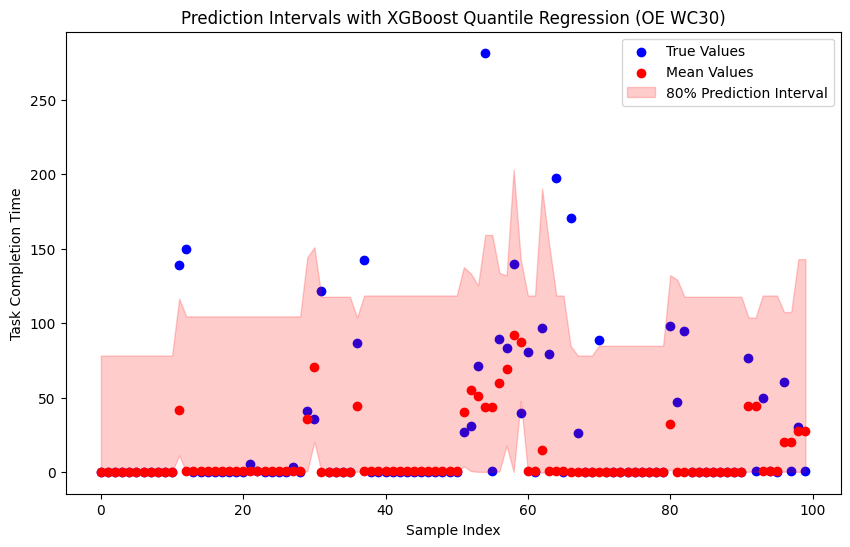

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test[:100])), y_test[:100], color="blue", label="True Values")
plt.scatter(range(len(preds_med[:100])), preds_med[:100], color="red", label="Mean Values")
plt.fill_between(range(len(y_test[:100])), preds_lower[:100], preds_upper[:100], color="red", alpha=0.2, label="80% Prediction Interval")
plt.xlabel("Sample Index")
plt.ylabel("Task Completion Time")
plt.title("Prediction Intervals with XGBoost Quantile Regression (OE WC30)")
plt.legend()
plt.show()

In [26]:
print(coverage)

0.4664918414918415


In [17]:
# Block-level evaluation
block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
if len(block_df) == 0:
    print(f"No valid blocks for WC {wc}")

temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
temp["pred_lower"] = preds_lower
temp["pred_med"] = preds_med
temp["pred_upper"] = preds_upper
block_rows_df = block_rows_df.merge(temp[["orig_index", "pred_lower", "pred_med", "pred_upper"]], on="orig_index", how="left")

block_pred = (
    block_rows_df.groupby("BlockID")
    .agg(
        actual_time=("Time_Delta_sec", "sum"),
        pred_med=("pred_med", "sum"),
        pred_lower=("pred_lower", np.median),
        pred_upper=("pred_upper", np.median),
        WorkCode=("WorkCode", "first"),
        UserID=("UserID", "first"),
        date=("date", "first"),
        n_tasks=("Time_Delta_sec", "size"),
    )
    .reset_index()
)

metrics_med = eval_predictions(block_pred["actual_time"], block_pred["pred_med"])
print(wc)
print(f"  Blocks: {len(block_pred)} | MAE: {metrics_med['mae']:.1f}s | "
    f"MAE/task: {metrics_med['mae']/BLOCK_SIZE:.3f}s | R²: {metrics_med['r2']:.4f}")

30
  Blocks: 328 | MAE: 216.9s | MAE/task: 10.843s | R²: -0.0766


In [22]:
# Block-level evaluation
block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
if len(block_df) == 0:
    print(f"No valid blocks for WC {wc}")

temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
temp["pred_lower"] = preds_lower
temp["pred_med"] = preds_med
temp["pred_upper"] = preds_upper
block_rows_df = block_rows_df.merge(temp[["orig_index", "pred_lower", "pred_med", "pred_upper"]], on="orig_index", how="left")

block_pred = (
    block_rows_df.groupby("BlockID")
    .agg(
        actual_time=("Time_Delta_sec", np.mean),
        pred_med=("pred_med", np.mean),
        pred_lower=("pred_lower", np.mean),
        pred_upper=("pred_upper", np.mean),
        WorkCode=("WorkCode", "first"),
        UserID=("UserID", "first"),
        date=("date", "first"),
        n_tasks=("Time_Delta_sec", "size"),
    )
    .reset_index()
)

metrics_med = eval_predictions(block_pred["actual_time"], block_pred["pred_med"])
print(wc)
print(f"  Blocks: {len(block_pred)} | MAE: {metrics_med['mae']:.1f}s | "
    f"MAE/task: {metrics_med['mae']/BLOCK_SIZE:.3f}s | R²: {metrics_med['r2']:.4f}")

30
  Blocks: 328 | MAE: 10.8s | MAE/task: 0.542s | R²: -0.0766


In [23]:
block_pred

,BlockID,actual_time,pred_med,pred_lower,pred_upper,WorkCode,UserID,date,n_tasks
0,143_2025-12-02_0,59.03215,33.873760,2.909675,152.190781,30,143,2025-12-02,20
1,221_2025-12-02_0,49.28750,36.493462,1.743140,158.093185,30,221,2025-12-02,20
2,221_2025-12-02_1,61.61150,39.074444,1.664136,166.044632,30,221,2025-12-02,20
3,221_2025-12-02_10,38.33785,28.268169,0.826361,134.532333,30,221,2025-12-02,20
4,221_2025-12-02_11,36.52585,30.031473,1.780882,131.432388,30,221,2025-12-02,20
...,...,...,...,...,...,...,...,...,...
323,67_2025-12-02_6,27.39400,28.700420,1.609571,148.509201,30,67,2025-12-02,20
324,67_2025-12-02_7,32.26700,31.487879,2.303045,146.542862,30,67,2025-12-02,20
325,67_2025-12-02_8,64.32685,37.518917,2.588003,145.845062,30,67,2025-12-02,20
326,67_2025-12-02_9,54.46765,33.351112,2.561975,145.093338,30,67,2025-12-02,20


Coverage: 0.9451219512195121


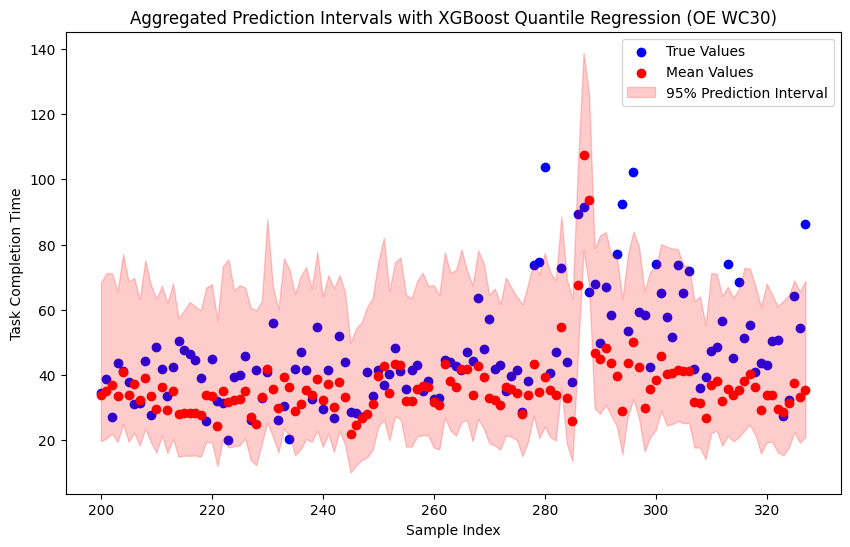

In [28]:
n_tasks = block_pred["n_tasks"][0]
std = np.std(block_pred["pred_med"])
agg_actual = block_pred["actual_time"]
agg_med = block_pred["pred_med"]
agg_lower = agg_med - ((agg_med - block_pred["pred_lower"])/np.sqrt(n_tasks)) - std
agg_upper = agg_med + ((block_pred["pred_upper"] - agg_med)/np.sqrt(n_tasks)) + std

agg_coverage = np.mean((agg_lower <= agg_actual) & (agg_actual <= agg_upper))
print(f"Coverage: {agg_coverage}")

plt.figure(figsize=(10, 6))
plt.scatter(range(len(agg_actual))[200:], agg_actual[200:], color="blue", label="True Values")
plt.scatter(range(len(agg_med))[200:], agg_med[200:], color="red", label="Mean Values")
plt.fill_between(range(len(agg_actual))[200:], agg_lower[200:], agg_upper[200:], color="red", alpha=0.2, label="95% Prediction Interval")
plt.xlabel("Sample Index")
plt.ylabel("Task Completion Time")
plt.title("Aggregated Prediction Intervals with XGBoost Quantile Regression (OE WC30)")
plt.legend()
plt.show()

In [4]:
block_results_clean = block_results_df.copy()
for c in ["r2", "mae", "rmse"]:
    if c in block_results_clean.columns:
        block_results_clean[c] = block_results_clean[c].round(3)
block_results_clean["mae_per_task"] = (block_results_clean["mae"] / BLOCK_SIZE).round(3)
block_results_clean = block_results_clean.drop(columns=["rmse", "Warehouse"], errors="ignore")

print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")
display(block_results_clean.sort_values(["WorkCode", "mae_per_task"]).reset_index(drop=True))


Warehouse: OE | Block size: 50 tasks


,WorkCode,n_blocks,r2,mae,mae_per_task
0,10,6,-1.074,1086.444,21.729
1,20,55,0.553,346.026,6.921
2,30,123,0.260,365.594,7.312


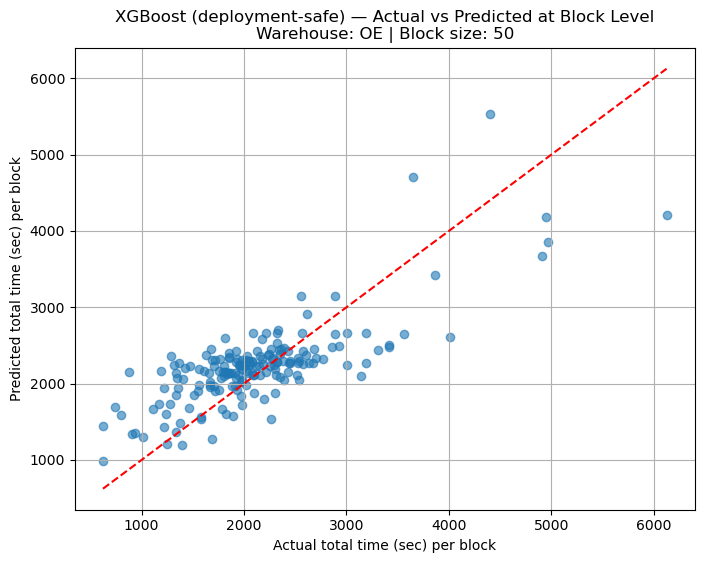

In [5]:
plot_df = block_detail_df[block_detail_df["Warehouse"] == WAREHOUSE].copy()
plot_df = plot_df[plot_df["pred"].notna()].copy()

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["actual_time"], plot_df["pred"], alpha=0.6)
plt.plot(
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    color="red", linestyle="--"
)
plt.xlabel("Actual total time (sec) per block")
plt.ylabel("Predicted total time (sec) per block")
plt.title(f"XGBoost (deployment-safe) — Actual vs Predicted at Block Level\n"
          f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE}")
plt.grid(True)
plt.show()


In [6]:
df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, "30", MAX_TIME)
print(features)


['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']


In [7]:
# ── Worker Random Intercept (Mixed Effects) ────────────────────────────────
# Fits Time_Delta_sec ~ 1 + (1|UserID) on training data only.
# Extracts per-worker effect b_j and adds it as a feature to XGBoost.
# Unseen workers at test time get effect = 0 (grand mean fallback).

def estimate_worker_effects(train_df):
    """
    Fits a random intercept model on training data.
    Returns a DataFrame with columns [UserID, worker_effect].
    worker_effect is the b_j estimate: positive = slower than average.
    """
    df_re = train_df[["UserID", "Time_Delta_sec"]].dropna().copy()
    if df_re["UserID"].nunique() < 2:
        print("  [Warning] Not enough workers — skipping worker effects")
        return pd.DataFrame({"UserID": df_re["UserID"].unique(), "worker_effect": 0.0})

    result = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
    ).fit(reml=True, disp=False)

    icc = result.cov_re.values[0][0] / (result.cov_re.values[0][0] + result.scale)
    print(f"  Grand mean: {result.fe_params['Intercept']:.1f}s | "
          f"Worker SD: {np.sqrt(result.cov_re.values[0][0]):.1f}s | ICC: {icc:.3f}")

    return pd.DataFrame({
        "UserID":        list(result.random_effects.keys()),
        "worker_effect": [float(v.iloc[0]) for v in result.random_effects.values()]
    })


all_block_results_w = []
all_block_detail_w  = []

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc} — + Worker Effect")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, test_days = split_by_days(df_wc)

    # Estimate worker effects on training data only — no leakage
    print("  Fitting mixed model...")
    worker_effects = estimate_worker_effects(train_df)

    # Join worker_effect — unseen workers get 0 (grand mean fallback)
    train_df = train_df.merge(worker_effects, on="UserID", how="left")
    test_df  = test_df.merge(worker_effects,  on="UserID", how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"]  = test_df["worker_effect"].fillna(0.0)

    # Reset index — critical for block index alignment
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    y_train  = train_df["Time_Delta_sec"].astype(float)
    y_test   = test_df["Time_Delta_sec"].astype(float)

    # Add worker_effect to feature set
    feats_w = features + ["worker_effect"]
    X_train, X_test = make_X(train_df, test_df, feats_w, cat_cols)

    t0    = time.perf_counter()
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    runtime = time.perf_counter() - t0

    # Block-level evaluation
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_df) == 0:
        print(f"  No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred"] = preds
    block_rows_df = block_rows_df.merge(temp[["orig_index", "pred"]], on="orig_index", how="left")

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred=("pred", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
    print(f"  Blocks: {len(block_pred)} | MAE: {metrics['mae']:.1f}s | "
          f"MAE/task: {metrics['mae']/BLOCK_SIZE:.3f}s | R²: {metrics['r2']:.4f}")

    all_block_results_w.append({
        "Warehouse": WAREHOUSE,
        "WorkCode":  wc,
        "n_blocks":  len(block_pred),
        **metrics
    })
    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail_w.append(block_pred)

block_results_w_df = pd.DataFrame(all_block_results_w)
block_detail_w_df  = pd.concat(all_block_detail_w, ignore_index=True) if all_block_detail_w else pd.DataFrame()
print("\nDone.")



WorkCode 10 — + Worker Effect
  Fitting mixed model...
  Grand mean: 83.8s | Worker SD: 12.4s | ICC: 0.043
  Blocks: 6 | MAE: 771.9s | MAE/task: 15.439s | R²: -0.3658

WorkCode 20 — + Worker Effect
  Fitting mixed model...


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034
  Blocks: 55 | MAE: 438.4s | MAE/task: 8.769s | R²: 0.2589

WorkCode 30 — + Worker Effect
  Fitting mixed model...
  Grand mean: 60.9s | Worker SD: 22.4s | ICC: 0.210
  Blocks: 123 | MAE: 259.0s | MAE/task: 5.179s | R²: 0.6623

Done.


In [12]:
# extract all worker effects
worker_effects_all = []
for wc in WORKCODES:
    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, _, _ = split_by_days(df_wc)
    worker_effects = estimate_worker_effects(train_df)
    worker_effects["WorkCode"] = wc
    worker_effects_all.append(worker_effects)
worker_effects_df = pd.concat(worker_effects_all, ignore_index=True)

  Grand mean: 83.8s | Worker SD: 12.4s | ICC: 0.043


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034
  Grand mean: 60.9s | Worker SD: 22.4s | ICC: 0.210


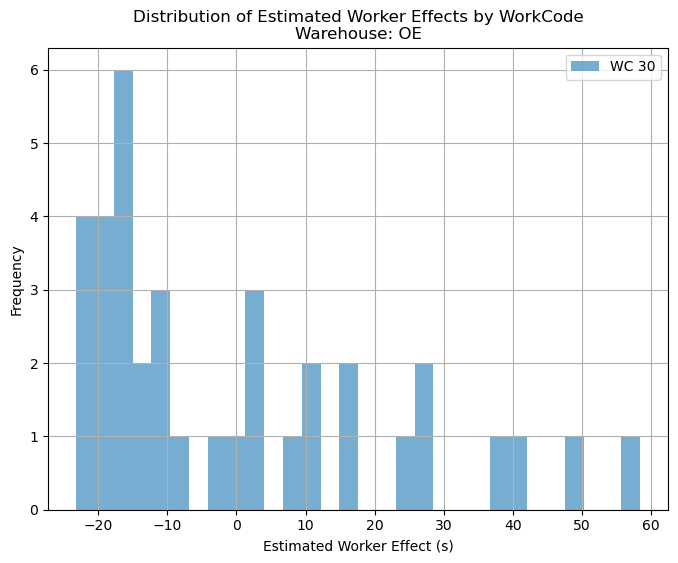

Worker Effect Percentiles for WC 30:
  10th percentile: -20.4s
  25th percentile: -17.1s
  50th percentile: -9.8s
  75th percentile: 11.5s
  90th percentile: 31.3s
  Mean: -0.0s


In [14]:
plt.figure(figsize=(8, 6))
subset = worker_effects_df[worker_effects_df["WorkCode"] == "30"]
plt.hist(subset["worker_effect"], bins=30, alpha=0.6, label=f"WC 30")
plt.xlabel("Estimated Worker Effect (s)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Estimated Worker Effects by WorkCode\nWarehouse: {WAREHOUSE}")
plt.legend()
plt.grid(True)
plt.show()

# compute 10, 25, 50, mean, 75, 90 percentiles of worker effects for WC 30
percentiles = [10, 25, 50, 75, 90]
percentile_values = np.percentile(subset["worker_effect"], percentiles)
print(f"Worker Effect Percentiles for WC 30:")
for p, val in zip(percentiles, percentile_values):
    print(f"  {p}th percentile: {val:.1f}s")
print(f"  Mean: {subset['worker_effect'].mean():.1f}s")


In [8]:
# Compare baseline vs + worker at chunk level
rows = []
for wc in WORKCODES:
    base = block_results_df[block_results_df["WorkCode"] == wc]
    enh  = block_results_w_df[block_results_w_df["WorkCode"] == wc]
    if base.empty or enh.empty:
        continue
    mae_base = base["mae"].values[0]
    mae_enh  = enh["mae"].values[0]
    rows.append({
        "WorkCode":              wc,
        "MAE/task baseline (s)": round(mae_base / BLOCK_SIZE, 3),
        "MAE/task + worker (s)": round(mae_enh  / BLOCK_SIZE, 3),
        "Improvement (s)":       round((mae_base - mae_enh) / BLOCK_SIZE, 3),
        "Improvement (%)": round((mae_base - mae_enh) / mae_base * 100, 2),
        "R² baseline":           round(base["r2"].values[0], 4),
        "R² + worker":           round(enh["r2"].values[0],  4),
    })

print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")
display(pd.DataFrame(rows))


Warehouse: OE | Block size: 50 tasks


,WorkCode,MAE/task baseline (s),MAE/task + worker (s),Improvement (s),Improvement (%),R² baseline,R² + worker
0,10,21.729,15.439,6.290,28.95,-1.0736,-0.3658
1,20,6.921,8.769,-1.848,-26.71,0.5527,0.2589
2,30,7.312,5.179,2.133,29.17,0.2596,0.6623


# WC30 — strong positive result
Worker effects help significantly. MAE/task drops from 7.312s to 5.179s, a 29% improvement, and R² jumps from 0.26 to 0.66. This is consistent with what you found in your earlier notebooks. The ICC of 0.210 confirms worker identity explains 21% of pick time variance, and the model is successfully capturing that. This is your headline result.

# WC10 — improvement but thin evidence
MAE/task drops from 21.729s to 15.439s, a 29% improvement. But both R² values are negative (-1.07 and -0.37), meaning both models are worse than just predicting the mean. With only 6 test blocks this result is unreliable — 6 blocks is not enough to draw conclusions. The improvement direction is consistent with WC30 but the absolute performance is poor. The ICC of 0.043 means worker signal is weak here too. Flag as low confidence.

# WC20 — worker effects hurt
This is the same WC20 problem you've seen throughout. MAE/task goes from 6.921s to 8.769s, getting 27% worse when adding worker effects. ICC is 0.034 — almost no worker signal. The convergence warning confirms the model is struggling. This is the same artifact as before — weak worker signal, single test day, noisy estimates. The worker effect is adding noise rather than signal for WC20 in this warehouse with these deployment-safe features.

# The overall conclusion
Worker effects are helpful where worker signal is strong (WC30, ICC=0.21) and neutral or harmful where it's weak (WC20, ICC=0.034). This is exactly what the theory predicts — partial pooling helps when there's real signal to capture, but when ICC is near zero the worker estimates are mostly noise and adding them as a feature can hurt. Your final model recommendation should acknowledge this WorkCode dependency.